## 3A.Dropout

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
import pandas as pd
import importlib
import sys
import os

sys.path.append(os.path.abspath(".."))  

import src.utils as utils
import src.utils as utils
importlib.reload(utils)

from src.utils import train_and_evaluate

from src.utils import load_and_split_data




In [ ]:
# Define a medium complexity CNN model with dropout layers
def Medium_model_with_dropout(dropout_rate=0.0):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Dropout(dropout_rate),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Dropout(dropout_rate),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),

        layers.Dropout(dropout_rate),

        layers.Dense(10, activation='softmax')
    ])
    return model


In [13]:
# Define different dropout rates to test
x_train, y_train, x_val, y_val, x_test, y_test = load_and_split_data()

configs = {
    "D0": 0.0,
    "D1": 0.25,
    "D2": 0.5
}

results = []
histories = {}

for name, rate in configs.items():
    model = Medium_model_with_dropout(rate)

    model.compile(
        optimizer=keras.optimizers.Adam(0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print(f"\nTraining {name}...")

    history, acc, loss, t = train_and_evaluate(
        model,
        x_train, y_train,
        x_val, y_val,
        x_test, y_test,
        epochs=30
    )

    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    gap = train_acc - val_acc

    results.append((name, train_acc, val_acc, acc, gap))
    histories[name] = history


Training D0...
Test Acc: 0.6256 | Test Loss: 3.5727 | Time:3087.0s

Training D1...
Test Acc: 0.7356 | Test Loss: 0.8846 | Time:7859.0s

Training D2...
Test Acc: 0.7331 | Test Loss: 0.7687 | Time:3628.9s


In [14]:
# Display results in a DataFrame
df = pd.DataFrame(results, columns=[
    "Model", "Train Acc", "Val Acc", "Test Acc", "Overfit Gap"
])
df

,Model,Train Acc,Val Acc,Test Acc,Overfit Gap
0,D0,0.969025,0.6270,0.6256,0.342025
1,D1,0.852000,0.7473,0.7356,0.104700
2,D2,0.699950,0.7442,0.7331,-0.044250


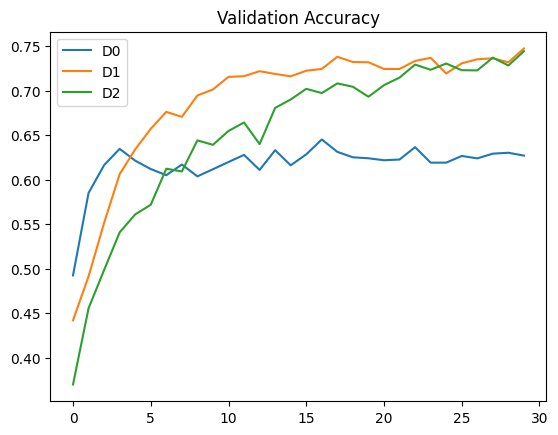

In [15]:
# Plot validation accuracy curves
plt.figure()
for name, h in histories.items():
    plt.plot(h.history['val_accuracy'], label=name)

plt.title("Validation Accuracy")
plt.legend()
plt.show()

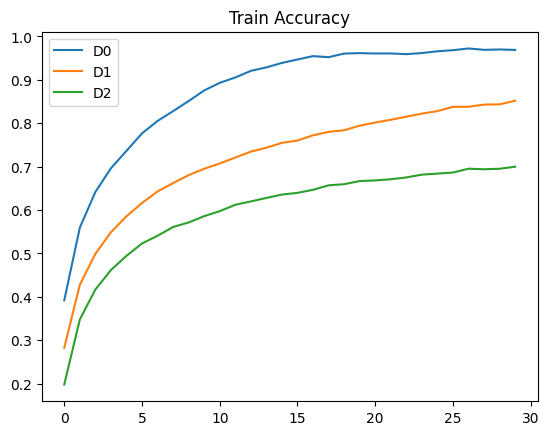

In [16]:
# Plot training accuracy curves
plt.figure()
for name, h in histories.items():
    plt.plot(h.history['accuracy'], label=name)

plt.title("Train Accuracy")
plt.legend()
plt.show()

## 3B.EarlyStopping

In [3]:
from tensorflow.keras import callbacks
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
import pandas as pd
import importlib
import src.utils as utils
importlib.reload(utils)

from src.utils import train_and_evaluate
from src.utils import BaselineCNN
from src.utils import run_Experiment_C






In [4]:
es2 = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

es3 = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [9]:
experiments = {
    "ES0": None,
    "ES2": es2,
    "ES3": es3
}

results_es = []
hist_es = {}

for name, cb in experiments.items():
    model = Medium_model_with_dropout(0.0)

    model.compile(
        optimizer=keras.optimizers.Adam(0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print(f"\nTraining {name}...")

    history = model.fit(
        x_train, to_categorical(y_train,10),
        validation_data=(x_val, to_categorical(y_val,10)),
        epochs=50,
        batch_size=128,
        callbacks=[cb] if cb else [],
        verbose=0
    )

    stopped_epoch = len(history.history['loss'])
    best_val_loss = min(history.history['val_loss'])

    test_loss, test_acc = model.evaluate(
        x_test, to_categorical(y_test,10), verbose=0
    )

    results_es.append((name, stopped_epoch, best_val_loss, test_acc))
    hist_es[name] = history


Training ES0...

Training ES2...

Training ES3...


In [10]:
df_es = pd.DataFrame(results_es, columns=[
    "Experiment", "Stopped Epoch", "Best Val Loss", "Test Acc"
])
df_es

,Experiment,Stopped Epoch,Best Val Loss,Test Acc
0,ES0,50,1.180031,0.6167
1,ES2,8,1.129918,0.6053
2,ES3,12,1.135123,0.6032


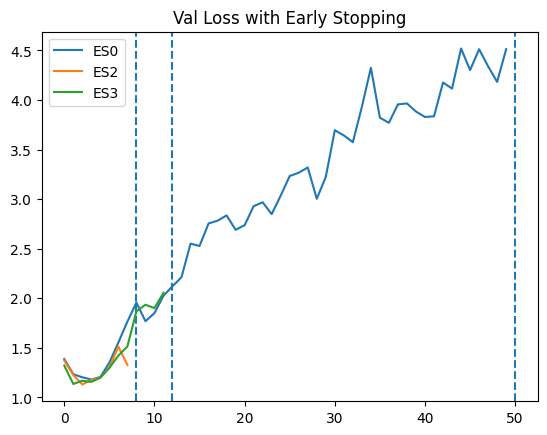

In [11]:
plt.figure()

for name, h in hist_es.items():
    plt.plot(h.history['val_loss'], label=name)

    stop_epoch = len(h.history['val_loss'])
    plt.axvline(stop_epoch, linestyle='--')

plt.legend()
plt.title("Val Loss with Early Stopping")
plt.show()